First, I import the libraries needed for the analysis. 
NumPy and pandas are used for handling and working with the data, 
while matplotlib is used to create visualisations.

I also import DstApi, which allows me to retrieve data directly from Statistics Denmark.

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dstapi import DstApi

Accessing the data from Statistics Denmark

In [93]:
IFOR41 = DstApi('IFOR41')

Exploring the available variables.

In [94]:
IFOR41.variable_levels('ULLIG', language='en')

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


Before selecting the data, we examine the available values for the municipality variable. Since the analysis is for all of Denmark we wil filter this out later, so it is not for individual municipalities

In [95]:
IFOR41.variable_levels('KOMMUNEDK', language='en')

,id,text
0,000,All Denmark
1,101,Copenhagen
2,147,Frederiksberg
3,155,Dragør
4,185,Tårnby
...,...,...
94,773,Morsø
95,840,Rebild
96,787,Thisted
97,820,Vesthimmerlands


Here, we define which data we want to retrieve from Statistics Denmark. we select the Gini coefficient for all of Denmark and all available years.

In [96]:
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

We now retrieve the selected data and display the first rows to check that it was downloaded correctly.

In [97]:
gini = IFOR41.get_data(params=params)

gini.head()

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


The below cell gives us an overview of the gini

In [98]:
gini.describe()

,TID
count,38.000000
mean,2005.500000
std,11.113055
min,1987.000000
25%,1996.250000
50%,2005.500000
75%,2014.750000
max,2024.000000


Cleaning the data by changing the gini to a float

In [99]:
gini['INDHOLD'] = gini['INDHOLD'].astype(float)

Further clean up of the data by removing unnecessary columns and renaming the remaining ones for clarity.

In [100]:
gini = gini.drop(columns=['ULLIG', 'KOMMUNEDK'])

gini = gini.rename(columns={
    'TID': 'year',
    'INDHOLD': 'gini'
})

Overview

In [101]:
gini.head()

,year,gini
0,2016,28.97
1,1999,23.83
2,1988,22.06
3,2015,28.77
4,1989,21.93


We can see that the years is not sorted, so we will sort the years in ascending order.

In [102]:
gini = gini.sort_values('year')

Checking

In [103]:
gini.head()

,year,gini
16,1987,22.07
2,1988,22.06
4,1989,21.93
30,1990,22.16
25,1991,21.99


The data is now as we wished with the wears in ascending order and we can now make a figure showing us the gini coefficient in Denmark over time. We have that gini is the name of our dataframe.

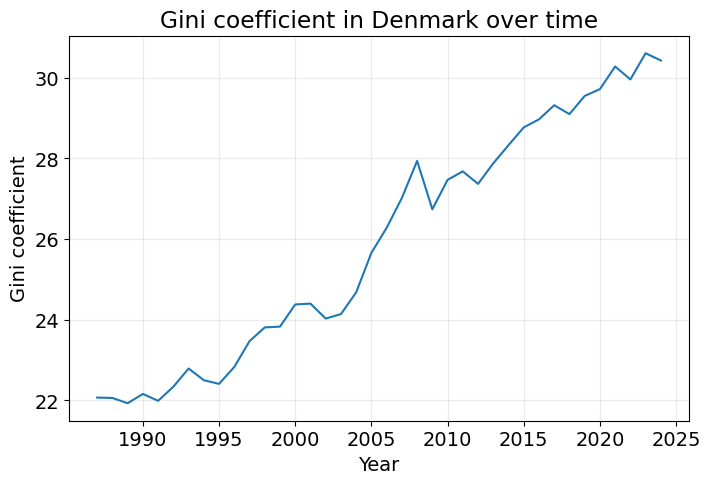

In [104]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(gini['year'], gini['gini'])

ax.set_title('Gini coefficient in Denmark over time')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

plt.show()

We now move on the second part of question 1.1. We wish to see the share of income going to the richest 10 percent.

We make a connection to IFOR32, and have from the begining of this notebook already downloadet the necessary stuff.

In [105]:
IFOR32 = DstApi('IFOR32')

Here we get an overview of the table, and set the language to english

In [106]:
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [107]:
IFOR32.variable_levels('DECILGEN', language='en')

,id,text
0,1DC,First decil
1,2DC,Second decil
2,3DC,Third decil
3,4DC,Fourth decil
4,5DC,Fifth decil
5,6DC,Sixth decil
6,7DC,Seventh decil
7,8DC,Eigth decil
8,9DC,Ninth decil
9,10DC,Tenth decil


We now specify the data we want from IFOR32. We select all ten income deciles, all years, and All Denmark.

In [108]:


params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

income = IFOR32.get_data(params=params)

income.head()

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,First decil,All Denmark,2013,75704
1,Second decil,All Denmark,2013,140049
2,Third decil,All Denmark,2013,163582
3,Fourth decil,All Denmark,2013,185931
4,Fifth decil,All Denmark,2013,209384


In [109]:
#Makes the dataset ready

income['INDHOLD'] = income['INDHOLD'].astype(float)

income = income.drop(columns=['KOMMUNEDK'])

income = income.rename(columns={
    'DECILGEN': 'decil',
    'TID': 'year',
    'INDHOLD': 'income'
})

income.head()

,decil,year,income
0,First decil,2013,75704.0
1,Second decil,2013,140049.0
2,Third decil,2013,163582.0
3,Fourth decil,2013,185931.0
4,Fifth decil,2013,209384.0


In [110]:
# Makes the decils to numbers from 1 to 10

decil_map = {
    'First decil': 1,
    'Second decil': 2,
    'Third decil': 3,
    'Fourth decil': 4,
    'Fifth decil': 5,
    'Sixth decil': 6,
    'Seventh decil': 7,
    'Eighth decil': 8,
    'Ninth decil': 9,
    'Tenth decil': 10
}

income['decil'] = income['decil'].map(decil_map)

income = income.sort_values(['year', 'decil'])

income.head(10)

,decil,year,income
260,1.0,1987,31418.0
261,2.0,1987,59014.0
262,3.0,1987,68786.0
263,4.0,1987,77577.0
264,5.0,1987,85361.0
265,6.0,1987,92777.0
266,7.0,1987,100691.0
268,9.0,1987,123582.0
269,10.0,1987,169598.0
267,NaN,1987,110184.0


In [111]:
# Fixing the missing 8th decil

income.loc[income['decil'].isna(), 'decil'] = 8

income = income.sort_values(['year', 'decil'])

income.head(10)

,decil,year,income
260,1.0,1987,31418.0
261,2.0,1987,59014.0
262,3.0,1987,68786.0
263,4.0,1987,77577.0
264,5.0,1987,85361.0
265,6.0,1987,92777.0
266,7.0,1987,100691.0
267,8.0,1987,110184.0
268,9.0,1987,123582.0
269,10.0,1987,169598.0


The data have now been cleaned, and is ready for an analysis

In [112]:

income.groupby('decil')['income'].mean()

decil
1.0      63079.421053
2.0     115863.105263
3.0     135364.131579
4.0     153987.868421
5.0     172573.789474
6.0     191304.500000
7.0     211895.736842
8.0     237253.973684
9.0     274808.763158
10.0    443505.631579
Name: income, dtype: float64

Will now make a figure over the development of the decil groups over the years.

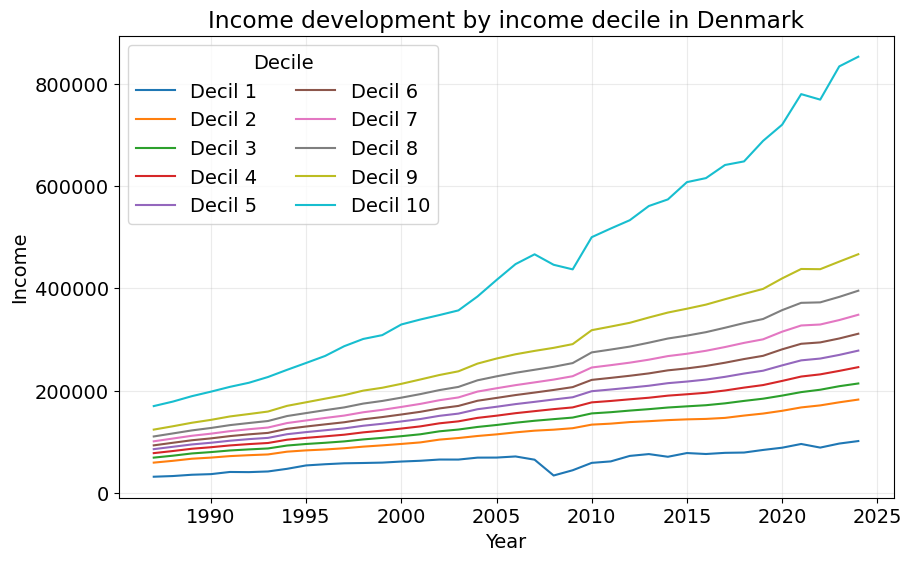

In [113]:
fig, ax = plt.subplots(figsize=(10, 6))

for decil in range(1, 11):
    data = income[income['decil'] == decil]
    ax.plot(data['year'], data['income'], label=f'Decil {decil}')

ax.set_title('Income development by income decile in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Income')
ax.legend(title='Decile', ncol=2)

plt.show()

Will now make a further analysis to see the share of total income going to the richest 10%.

In [114]:
top10 = income[income['decil'] == 10].copy()

total_income = income.groupby('year')['income'].sum()

top10['top10_share'] = top10['income'] / top10['year'].map(total_income)

top10.head()

,decil,year,income,top10_share
269,10.0,1987,169598.0,0.184549
117,10.0,1988,178357.0,0.184289
349,10.0,1989,188967.0,0.184952
189,10.0,1990,197793.0,0.186415
179,10.0,1991,207208.0,0.186683


Makes it into percent

In [115]:
top10['top10_share'] = top10['top10_share'] * 100

top10.head()

,decil,year,income,top10_share
269,10.0,1987,169598.0,18.454866
117,10.0,1988,178357.0,18.428870
349,10.0,1989,188967.0,18.495170
189,10.0,1990,197793.0,18.641480
179,10.0,1991,207208.0,18.668346


Plot the share of total income received by the richest 10% over time.

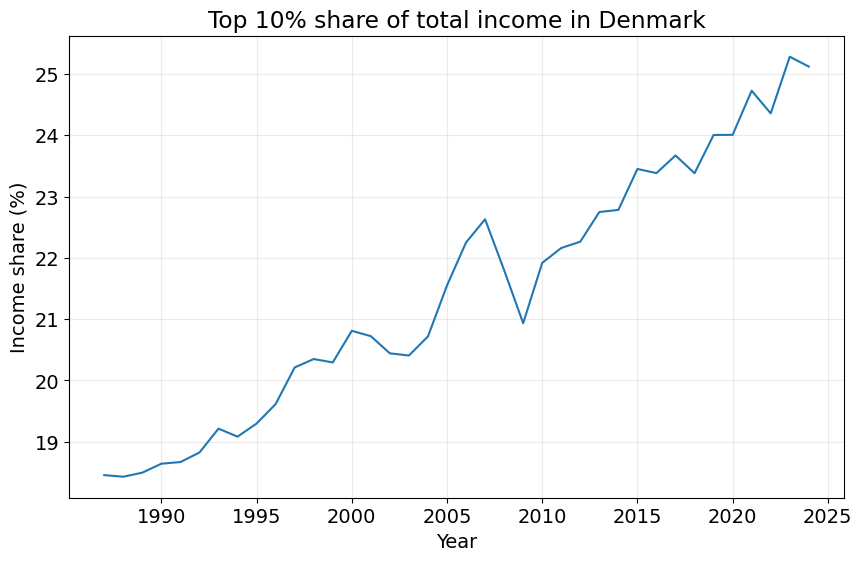

In [116]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(top10['year'], top10['top10_share'])

ax.set_title('Top 10% share of total income in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Income share (%)')

plt.show()

Computes the correlation of our two results 

In [117]:
analysis = pd.merge(
    gini[['year', 'gini']],
    top10[['year', 'top10_share']],
    on='year',
    validate='1:1'
)

analysis['top10_share'] = analysis['top10_share'] * 100

analysis.corr()

,year,gini,top10_share
year,1.000000,0.985228,0.982948
gini,0.985228,1.000000,0.981642
top10_share,0.982948,0.981642,1.000000


The two measures tell a very similar story about inequality in Denmark. Both measures show an overall increase in inequality since 1987, although there are some fluctuations over time. We can see that the correlation between them is 0.981642, which is very close to a perfect correlation of 1.

# 1.2

We will now begin on 1.2, first of all we see that t is set as years which we would want to change

In [118]:
gini['t'] = gini['year'] - 1987
gini.head()

,year,gini,t
16,1987,22.07,0
2,1988,22.06,1
4,1989,21.93,2
30,1990,22.16,3
25,1991,21.99,4


We will now start to build the function required for the linear trend.

In [119]:
def objective(beta):
    beta0, beta1 = beta
    prediction = beta0 + beta1 * gini['t']
    return ((gini['gini'] - prediction) ** 2).sum()

Uses the minimize function to find the optimal parameters for the linear regression model. 20 and 0 is start guesses.

In [120]:
from scipy.optimize import minimize

result = minimize(objective, [20, 0])
result.x

array([21.04275317,  0.26354961])

So the linear trend is Gini=21,04+0,26t

We have then found the optimal parameters for our linear regression model. The first parameter (beta0) represents the intercept, while the second parameter (beta1) represents the slope of the line.

In [121]:
import numpy as np

np.polyfit(gini['t'], gini['gini'], 1)

array([ 0.26354962, 21.04275304])

We then see, cheking the answers agains np.polyfit, that it is very similar and the minimazation worked

We will now move on and make the quadratic function. We will follow the same approach as before.

In [122]:
def objective_quad(beta):
    beta0, beta1, beta2 = beta
    prediction = beta0 + beta1 * gini['t'] + beta2 * gini['t']**2
    return ((gini['gini'] - prediction) ** 2).sum()

In [123]:
result_quad = minimize(objective_quad, [20, 0, 0])
result_quad.x

array([2.13041684e+01, 2.19980235e-01, 1.17754900e-03])

In [124]:
np.polyfit(gini['t'], gini['gini'], 2)

array([1.17769085e-03, 2.19975061e-01, 2.13042004e+01])

Again we see that the numbers fit the ones from the quadratic formula. We will now use our estimates to predict the gini coefficient.

In [125]:
years = np.array([2030, 2040])
t = years - 1987

linear_pred = result.x[0] + result.x[1] * t
quad_pred = result_quad.x[0] + result_quad.x[1] * t + result_quad.x[2] * t**2

print(pd.DataFrame({
    'Year': years,
    'Linear prediction': linear_pred,
    'Quadratic prediction': quad_pred
}))

   Year  Linear prediction  Quadratic prediction
0  2030          32.375387             32.940607
1  2040          35.010883             36.270856


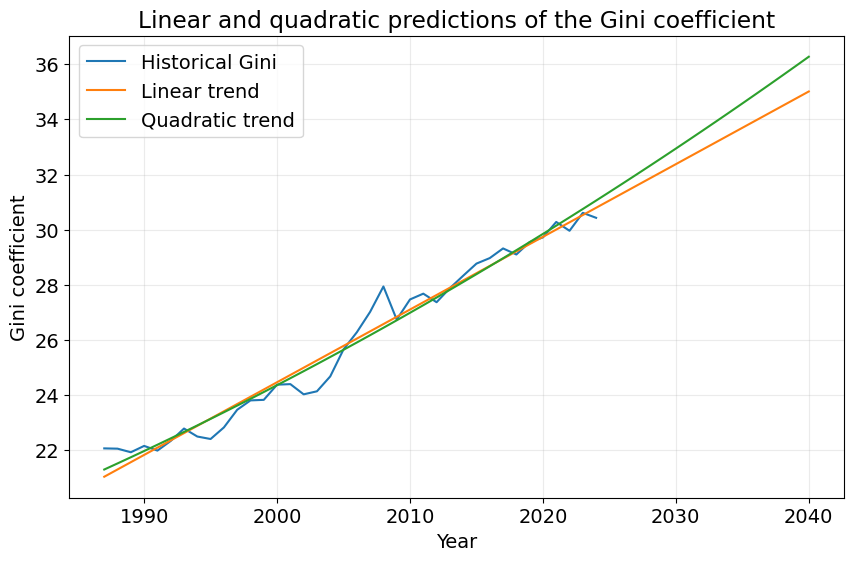

In [126]:
t_plot = np.arange(gini['t'].min(), 54)

plt.figure(figsize=(10, 6))
plt.plot(gini['year'], gini['gini'], label='Historical Gini')
plt.plot(t_plot + 1987, result.x[0] + result.x[1] * t_plot, label='Linear trend')
plt.plot(t_plot + 1987, result_quad.x[0] + result_quad.x[1] * t_plot + result_quad.x[2] * t_plot**2, label='Quadratic trend')

plt.xlabel('Year')
plt.ylabel('Gini coefficient')
plt.title('Linear and quadratic predictions of the Gini coefficient')
plt.legend()
plt.show()


Both models follow the overall upward trend in the historical Gini coefficient.

The linear model predicts 32.38 in 2030 and 35.01 in 2040, while the quadratic model predicts 32.94 and 36.27. The difference therefore increases over time.
It is seen in the figure that quadratic trend overall follows the historical gini a bit closer than the linear trend. It is however hard to trust any of the trends, due to the fact that it is a prediction where it is impossible to predict socioeconomic and political interference.

# 1.3